In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score,\
    f1_score, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GroupShuffleSplit,\
    GroupKFold, GridSearchCV, RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn import svm
from sklearn.svm import SVC
import lightgbm as lgb
import xgboost 

In [2]:
import os
import warnings
import pandas as pd
import features as f
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import statistics

warnings.filterwarnings('ignore')

parent = os.path.dirname(os.getcwd())

data = pd.read_csv(parent+"\\data\\MEM_New-Features_fastText.csv")
data.drop("Unnamed: 0", inplace=True, axis=1)
data.head()

,LISTID,PRESENTED_WORD,PRESENT_POSITION,HIT,PARTICIPANT_GROUP,MOST_SIM_VAL,MOST_SIM_DIST,AVG_SIM_PREV_1,AVG_CONTRAST_1,AVG_SIM_PREV_5,...,SAME_CLUSTER_IN_Z1,SAME_CLUSTER_IN_Z2,SAME_CLUSTER_IN_Z3,SAME_CLUSTER_IN_Z1_COUNT,SAME_CLUSTER_IN_Z2_COUNT,SAME_CLUSTER_IN_Z3_COUNT,CATEGORY_IN_STM_4,CATEGORY_IN_STM_1,CLUSTER,P_ID
0,1,KALEM,1,1,soc,NaN,NaN,NaN,0.661099,NaN,...,1,0,1,1,0,2,0,0,8,soc9
1,1,ÖLÇEK,2,0,soc,0.326431,1.0,0.326431,0.643500,0.326431,...,1,0,1,1,0,1,0,0,1,soc9
2,1,ÇANTA,3,0,soc,0.368361,2.0,0.098149,0.616813,0.233255,...,1,0,0,1,0,0,0,0,5,soc9
3,1,AĞAÇ,4,1,soc,0.462612,2.0,0.456668,0.504513,0.449454,...,1,0,1,1,0,1,0,0,9,soc9
4,1,PARK,5,0,soc,0.599958,1.0,0.599958,0.589818,0.338558,...,0,1,1,0,1,1,0,0,3,soc9


In [3]:
#FOR NOW, FILLING THESE IN WITH WHAT I THINK TO BE FIT 
#WILL EDIT, BUT I JUST REPLACE WITH MEAN TO NOT DISTURB THE DISTRIBUTION
#MAYBE WE CAN DO THIS: USE PARTICIPANT WIDE SIM CALCULATIONS, SO WE HAVE LESS NA.
#AND ON PREV WE CAN TURN INTO AVG_SIM, WHICH WILL INCLUDE LATER WORDS AS WELL
for col in data.columns:
    if data[col].isna().sum() > 0: 
        data[col] = data[col].fillna(np.mean(data[col]))
data.isna().sum()

LISTID                      0
PRESENTED_WORD              0
PRESENT_POSITION            0
HIT                         0
PARTICIPANT_GROUP           0
MOST_SIM_VAL                0
MOST_SIM_DIST               0
AVG_SIM_PREV_1              0
AVG_CONTRAST_1              0
AVG_SIM_PREV_5              0
AVG_CONTRAST_5              0
PREV_SIM                    0
STM_SEMANTIC_D              0
STM_MAX_SIM                 0
STM_MAX_SIM_DIST            0
STM_MAX_SIM_POS             0
UNIQUENESS                  0
PRESENT_ZONE                0
SAME_CLUSTER_IN_Z1          0
SAME_CLUSTER_IN_Z2          0
SAME_CLUSTER_IN_Z3          0
SAME_CLUSTER_IN_Z1_COUNT    0
SAME_CLUSTER_IN_Z2_COUNT    0
SAME_CLUSTER_IN_Z3_COUNT    0
CATEGORY_IN_STM_4           0
CATEGORY_IN_STM_1           0
CLUSTER                     0
P_ID                        0
dtype: int64

In [4]:
cols_categorical = ["LISTID", "PARTICIPANT_GROUP", "PRESENT_ZONE", "SAME_CLUSTER_IN_Z1",
                    "SAME_CLUSTER_IN_Z2", "SAME_CLUSTER_IN_Z3", "CATEGORY_IN_STM_4", "CATEGORY_IN_STM_1", "CLUSTER"]
cols_numeric = ["PRESENT_POSITION", "MOST_SIM_VAL", "MOST_SIM_DIST",
                "AVG_SIM_PREV_1", "AVG_CONTRAST_1", "AVG_SIM_PREV_5", "AVG_CONTRAST_5",
                "PREV_SIM","STM_SEMANTIC_D","STM_MAX_SIM","STM_MAX_SIM_DIST","STM_MAX_SIM_POS","UNIQUENESS",
                "SAME_CLUSTER_IN_Z1_COUNT", "SAME_CLUSTER_IN_Z2_COUNT", "SAME_CLUSTER_IN_Z3_COUNT"
                ]
target = data["HIT"]
data = data.drop(["HIT", "PRESENTED_WORD"], axis = 1)

In [5]:
X_df = data[cols_categorical + cols_numeric]
encoder = OneHotEncoder()

X_encoded = encoder.fit_transform(X_df[cols_categorical]).toarray()
encoded_feature_names = encoder.get_feature_names_out(cols_categorical)
encoded_feature_names = list(encoded_feature_names)

X_numeric = X_df[cols_numeric]

X_df = np.hstack([X_encoded, X_numeric])
X_df = pd.DataFrame(data = X_df, columns=encoded_feature_names+cols_numeric)

X_df

,LISTID_1,LISTID_2,LISTID_3,LISTID_4,PARTICIPANT_GROUP_eng,PARTICIPANT_GROUP_soc,PRESENT_ZONE_1,PRESENT_ZONE_2,PRESENT_ZONE_3,SAME_CLUSTER_IN_Z1_0,...,AVG_CONTRAST_5,PREV_SIM,STM_SEMANTIC_D,STM_MAX_SIM,STM_MAX_SIM_DIST,STM_MAX_SIM_POS,UNIQUENESS,SAME_CLUSTER_IN_Z1_COUNT,SAME_CLUSTER_IN_Z2_COUNT,SAME_CLUSTER_IN_Z3_COUNT
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.506092,0.329103,0.000000,1.000000,0.0,0.0,1.000000,1.0,0.0,2.0
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.547759,0.326431,0.000000,0.326431,1.0,0.0,0.661099,1.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.475856,0.098149,0.326431,0.368361,2.0,0.0,0.632386,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.397402,0.456668,0.792941,0.462612,2.0,1.0,0.486072,1.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.518097,0.599958,2.141305,0.599958,1.0,3.0,0.520607,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3031,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.452470,0.455540,2.218877,0.455540,1.0,11.0,0.487726,0.0,1.0,2.0
3032,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.553958,0.417808,2.264022,0.417808,1.0,12.0,0.571145,0.0,0.0,2.0
3033,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.546403,0.068836,1.659176,0.531414,4.0,10.0,0.586145,0.0,0.0,2.0
3034,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.546520,0.328398,1.342111,0.328398,1.0,14.0,0.609400,1.0,2.0,1.0


In [10]:
def Overviewer(estimator, param_grid, X_df, target, data, scoring = "recall", search = "grid"):
    """
    Blueprint function that acts like a pipeline
    estimator: function like SVC or KNearestNeighbors
    compares SMOTENC, SMOTEEEN, SMOTETomek, RandomUnderSampling
    """   
    groups = data["P_ID"].values
    y = target.values
    X = X_df.values

    # Split logic remains intact
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]

    cols_categorical_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8] 

    # 1. Initialize the base SMOTENC to handle the categorical indices
    base_smotenc = SMOTENC(categorical_features=cols_categorical_indices, random_state=42)

    # 2. Map all strategies into a dictionary. 
    # SMOTEENN and SMOTETomek require the base_smotenc object to handle mixed data correctly.
    samplers = {
        "SMOTENC": base_smotenc,
        "SMOTEENN": SMOTEENN(smote=base_smotenc, random_state=42),
        "SMOTETomek": SMOTETomek(smote=base_smotenc, random_state=42),
        "RandomUnderSampling": RandomUnderSampler(random_state=42)
    }

    gkf = GroupKFold(n_splits=3)
    
    # Optional: Consolidate ROC curves onto a single plot for easy comparison
    fig, ax = plt.subplots(figsize=(7.5, 6))

    # 3. Iterate through samplers to keep the pipeline DRY (Don't Repeat Yourself)
    for name, sampler in samplers.items():
        print(f"\n==========================================")
        print(f"=== {name.upper()} ===")
        print(f"==========================================")

        pipeline = ImbPipeline([
            ('sampler', sampler),
            ('scaler', StandardScaler()),
            ('estimator', estimator)
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=gkf,
            scoring=scoring, 
            n_jobs=-1
        )

        random_search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            cv=gkf,
            scoring=scoring, 
            n_jobs=-1,
            n_iter= 100
        )

        if search == "random":
            random_search.fit(X_train, y_train, groups=groups_train)
            best_model = random_search.best_estimator_

        if search == "grid":
            grid_search.fit(X_train, y_train, groups=groups_train)
            best_model = grid_search.best_estimator_
        
        y_pred_train = best_model.predict(X_train)
        y_pred_test = best_model.predict(X_test)

        print("=== TRAIN PERFORMANCE ===")
        print("Accuracy:", accuracy_score(y_train, y_pred_train))
        print(classification_report(y_train, y_pred_train))

        print("=== TEST PERFORMANCE ===")
        print("Accuracy:", accuracy_score(y_test, y_pred_test))
        print(classification_report(y_test, y_pred_test))
        
        # Overlay the ROC curve for this specific sampler on the shared axis
        RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax, name=name)
        
    plt.title("ROC Curves across Resampling Strategies")
    plt.show()



=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6434782608695652
              precision    recall  f1-score   support

           0       0.78      0.65      0.71      1621
           1       0.47      0.63      0.54       794

    accuracy                           0.64      2415
   macro avg       0.62      0.64      0.62      2415
weighted avg       0.68      0.64      0.65      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6006441223832528
              precision    recall  f1-score   support

           0       0.77      0.62      0.68       437
           1       0.38      0.57      0.46       184

    accuracy                           0.60       621
   macro avg       0.58      0.59      0.57       621
weighted avg       0.66      0.60      0.62       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.46542443064182193
              precision    recall  f1-score   support

           0       0.84      0.25      0.39      1621
           1       0.37      0.90    

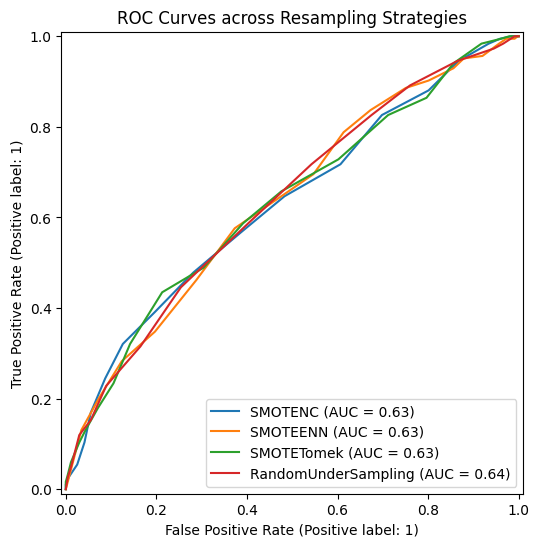

In [11]:
knn = KNeighborsClassifier()
param_grid = {
    'estimator__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'estimator__weights': ['uniform', 'distance'],        
    'estimator__metric': ['euclidean', 'manhattan']      
}
Overviewer(knn, param_grid, X_df, target, data)


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.5925465838509317
              precision    recall  f1-score   support

           0       0.73      0.63      0.67      1621
           1       0.41      0.52      0.46       794

    accuracy                           0.59      2415
   macro avg       0.57      0.57      0.57      2415
weighted avg       0.62      0.59      0.60      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6296296296296297
              precision    recall  f1-score   support

           0       0.78      0.65      0.71       437
           1       0.41      0.57      0.48       184

    accuracy                           0.63       621
   macro avg       0.60      0.61      0.60       621
weighted avg       0.67      0.63      0.64       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.5631469979296067
              precision    recall  f1-score   support

           0       0.73      0.55      0.63      1621
           1       0.39      0.60     

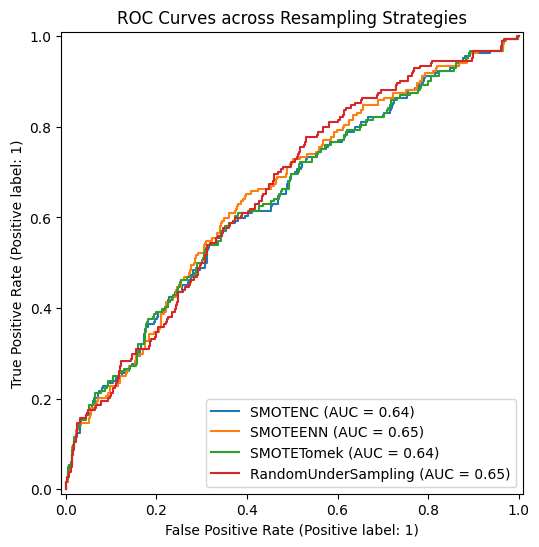

In [12]:
nb = GaussianNB()
param_grid = {}
Overviewer(nb, param_grid, X_df, target, data)


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6265010351966873
              precision    recall  f1-score   support

           0       0.74      0.68      0.71      1621
           1       0.44      0.52      0.48       794

    accuracy                           0.63      2415
   macro avg       0.59      0.60      0.59      2415
weighted avg       0.64      0.63      0.63      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6344605475040258
              precision    recall  f1-score   support

           0       0.77      0.68      0.72       437
           1       0.41      0.52      0.46       184

    accuracy                           0.63       621
   macro avg       0.59      0.60      0.59       621
weighted avg       0.66      0.63      0.65       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.3287784679089027
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1621
           1       0.33      1.00     

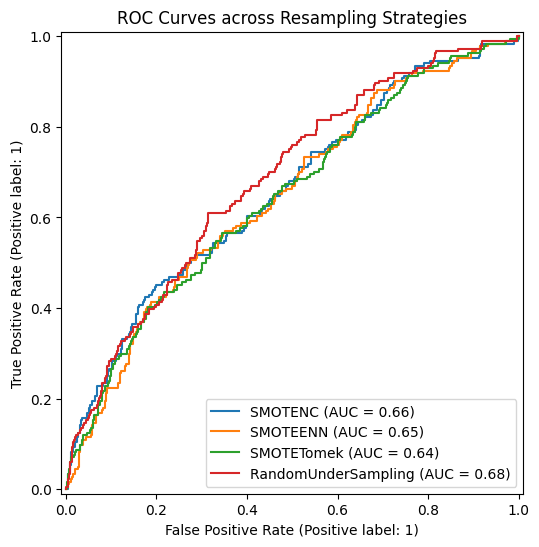

In [13]:
radial = SVC(kernel="rbf")
param_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}
Overviewer(radial, param_grid, X_df, target, data)



=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6728778467908902
              precision    recall  f1-score   support

           0       0.75      0.78      0.76      1621
           1       0.50      0.46      0.48       794

    accuracy                           0.67      2415
   macro avg       0.62      0.62      0.62      2415
weighted avg       0.67      0.67      0.67      2415

=== TEST PERFORMANCE ===
Accuracy: 0.677938808373591
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       437
           1       0.46      0.53      0.49       184

    accuracy                           0.68       621
   macro avg       0.63      0.64      0.63       621
weighted avg       0.69      0.68      0.68       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6770186335403726
              precision    recall  f1-score   support

           0       0.84      0.64      0.73      1621
           1       0.51      0.75      

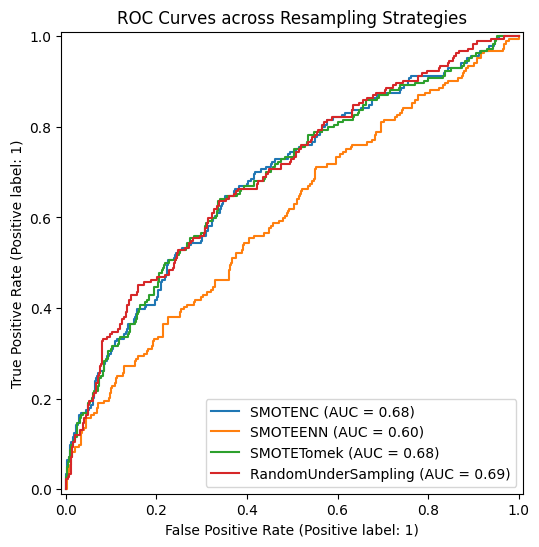

In [14]:
polynomial = SVC(kernel="poly", max_iter=10000)
param_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__degree': [2, 3],
    'estimator__gamma': ['scale', 0.01, 0.1, 1],
    'estimator__coef0': [0, 1, 2]
}
Overviewer(polynomial, param_grid, X_df, target, data, "f1_macro")


=== SMOTENC ===
[LightGBM] [Info] Number of positive: 1621, number of negative: 1621
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3973
[LightGBM] [Info] Number of data points in the train set: 3242, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

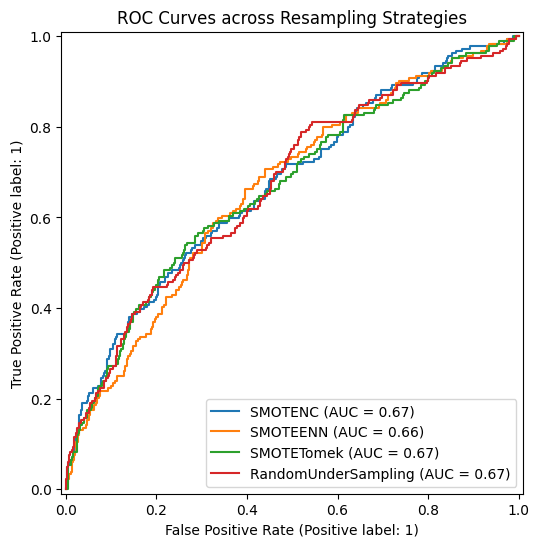

In [15]:
lgbm = lgb.LGBMClassifier()
param_grid = {
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [100, 500, 1000],
    'estimator__num_leaves': [31, 63, 127],
    'estimator__max_depth': [-1, 5, 8],
    'estimator__min_child_samples': [10, 20, 30],
    'estimator__subsample': [0.7, 0.8, 1.0],
    'estimator__colsample_bytree': [0.7, 0.8, 1.0]
}

Overviewer(lgbm, param_grid, X_df, target, data, scoring="f1_macro", search="random")



=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.7064182194616977
              precision    recall  f1-score   support

           0       0.75      0.85      0.80      1621
           1       0.57      0.41      0.48       794

    accuracy                           0.71      2415
   macro avg       0.66      0.63      0.64      2415
weighted avg       0.69      0.71      0.69      2415

=== TEST PERFORMANCE ===
Accuracy: 0.7053140096618358
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       437
           1       0.50      0.43      0.46       184

    accuracy                           0.71       621
   macro avg       0.64      0.63      0.63       621
weighted avg       0.69      0.71      0.70       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6695652173913044
              precision    recall  f1-score   support

           0       0.84      0.63      0.72      1621
           1       0.50      0.75     

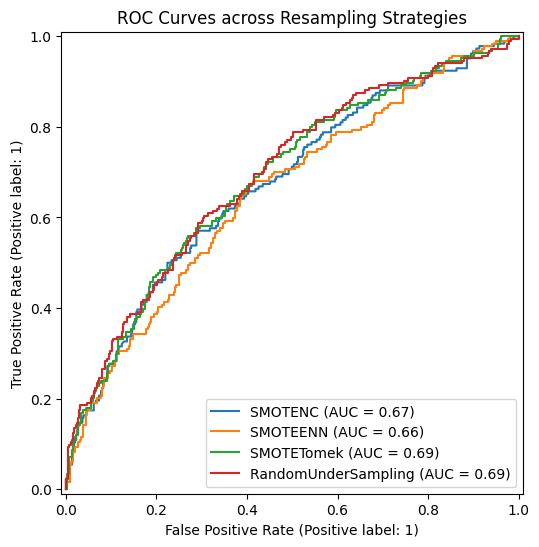

In [16]:
from random import randint, uniform
xgb = xgboost.XGBClassifier()
param_grid = {
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [100, 200, 500],
    'estimator__max_depth': [3, 5, 7],
    'estimator__min_child_weight': [1, 3, 5],
    'estimator__subsample': [0.7, 0.8, 1.0],
    'estimator__colsample_bytree': [0.7, 0.8, 1.0],
    'estimator__gamma': [0, 0.1, 0.2]
}
Overviewer(xgb, param_grid, X_df, target, data, "f1_macro","random")


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6318840579710145
              precision    recall  f1-score   support

           0       0.74      0.69      0.72      1621
           1       0.45      0.51      0.48       794

    accuracy                           0.63      2415
   macro avg       0.60      0.60      0.60      2415
weighted avg       0.65      0.63      0.64      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6618357487922706
              precision    recall  f1-score   support

           0       0.79      0.71      0.75       437
           1       0.44      0.54      0.49       184

    accuracy                           0.66       621
   macro avg       0.61      0.63      0.62       621
weighted avg       0.68      0.66      0.67       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.4153209109730849
              precision    recall  f1-score   support

           0       0.85      0.16      0.27      1621
           1       0.35      0.94     

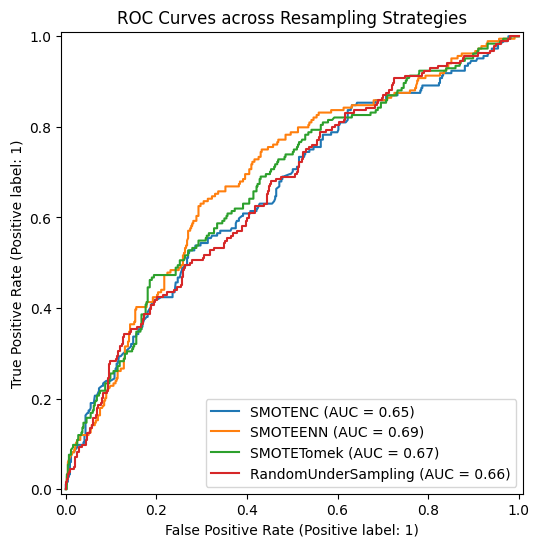

In [17]:
Overviewer(xgb, param_grid, X_df, target, data, "recall", "random")


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.7726708074534161
              precision    recall  f1-score   support

           0       0.77      0.93      0.85      1621
           1       0.77      0.44      0.56       794

    accuracy                           0.77      2415
   macro avg       0.77      0.69      0.70      2415
weighted avg       0.77      0.77      0.75      2415

=== TEST PERFORMANCE ===
Accuracy: 0.7230273752012882
              precision    recall  f1-score   support

           0       0.76      0.89      0.82       437
           1       0.56      0.33      0.41       184

    accuracy                           0.72       621
   macro avg       0.66      0.61      0.61       621
weighted avg       0.70      0.72      0.70       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6732919254658385
              precision    recall  f1-score   support

           0       0.85      0.63      0.72      1621
           1       0.50      0.77     

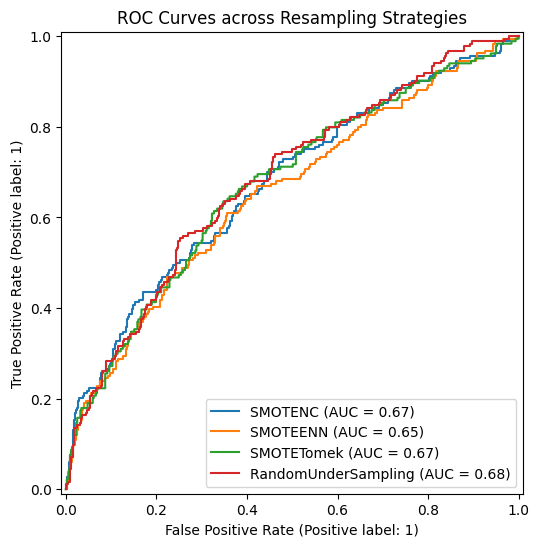

In [18]:
import catboost
cat = catboost.CatBoostClassifier(iterations=10, verbose=False)
param_grid = {
    'estimator__iterations': [500, 1000],
    'estimator__learning_rate': [0.03, 0.1],
    'estimator__depth': [4, 6, 8],
    'estimator__l2_leaf_reg': [1, 3, 5]
}

Overviewer(cat, param_grid, X_df, target, data, "f1_macro", "grid")

In [13]:
import keras
from keras import layers
import keras_tuner as kt
import tensorflow as tf
import tensorboard


groups = data["P_ID"].values
y = target.values
X = X_df.values

# Split logic remains intact
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]


X_train, X_test, y_train, y_test 
# 1. THE SCALING PIPELINE (Native Keras Preprocessing)
# This layer calculates mean/variance and normalizes data on the GPU
normalizer = layers.Normalization()
normalizer.adapt(X_train) # Fit the scaler to the training data only

# 2. THE ARCHITECTURE & TUNING PIPELINE
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.Input(shape=(45,)))
    
    # Apply the native scaling directly as the first layer
    model.add(normalizer) 
    
    # Tune the number of nodes for Layer 1
    hp_units_1 = hp.Int('units_layer_1', min_value=32, max_value=128, step=32)
    model.add(layers.Dense(units=hp_units_1, activation='relu'))
    model.add(layers.Dropout(0.2))
    
    # Tune the number of nodes for Layer 2 (UNIQUE NAME)
    hp_units_2 = hp.Int('units_layer_2', min_value=32, max_value=128, step=32)
    model.add(layers.Dense(units=hp_units_2, activation='relu'))
    model.add(layers.Dropout(0.2))

    # Static Hidden Layers
    model.add(layers.Dense(units=128, activation='relu'))
    model.add(layers.Dropout(0.2))

    # FIXED: Changed softmax to relu
    model.add(layers.Dense(units=64, activation='relu')) 
    model.add(layers.Dropout(0.2))

    model.add(layers.Dense(units=32, activation='relu'))
    model.add(layers.Dropout(0.2))
    
    # Output Layer (Correct for Binary Classification)
    model.add(layers.Dense(1, activation='sigmoid'))
    
    # Tune Learning Rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=50,
    factor=3,
    directory='my_tuning_dir',
    project_name='fnn_binary_classification',
    overwrite=True
)

# Execute the pipeline. Notice we handle the validation split natively here.
tuner.search(X_train, y_train, epochs=50, validation_split=0.2)

# Extract the tuned pipeline
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the model on the test set
results = best_model.evaluate(X_test, y_test, batch_size=32, verbose=1)

# results is a list: [loss, metric_1, metric_2, ...]
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

Trial 64 Complete [00h 00m 05s]
val_accuracy: 0.6749482154846191

Best val_accuracy So Far: 0.7142857313156128
Total elapsed time: 00h 04m 46s
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6973 - loss: 0.6153  
Test Loss: 0.6153
Test Accuracy: 0.6973


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Get raw probabilities from the network (Outputs shape: (n_samples, 1))
y_pred_probs = best_model.predict(X_test)

# 2. Threshold the probabilities to get binary classes (0 or 1)
# Using 0.5 is standard, but you can adjust this if you need higher recall!
y_pred_classes = (y_pred_probs > 0.38).astype(int)

# 3. Print the classification report (using the integer classes)
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_classes))

# 4. Print the Confusion Matrix
print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred_classes))

# 5. Calculate ROC-AUC (Note: ALWAYS use probabilities for ROC-AUC, not classes!)
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC-AUC Score: {roc_auc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.74      0.54      0.62       437
           1       0.34      0.55      0.42       184

    accuracy                           0.54       621
   macro avg       0.54      0.55      0.52       621
weighted avg       0.62      0.54      0.56       621

=== CONFUSION MATRIX ===
[[235 202]
 [ 82 102]]
ROC-AUC Score: 0.5997
